In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from photutils.centroids import centroid_sources, centroid_2dg
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u

from pathlib import Path


In [2]:
INPUT_PATH = Path("~/Research/AsTrovello/Input/").expanduser()
hst_suffix = "PHANGS-HST/galaxies/ngc1087/hlsp_phangs-hst_hst_wfc3-uvis_ngc1087_f814w_v1_exp-drc-sci.fits"
jwst_suffix = "PHANGS-JWST/galaxies/ngc1087/hlsp_phangs-jwst_jwst_nircam_ngc1087_f200w_v1p1_img.fits"

hst_file = INPUT_PATH / hst_suffix
jwst_file = INPUT_PATH / jwst_suffix


In [3]:
with fits.open(hst_file) as hdu_hst, fits.open(jwst_file) as hdu_jwst:
    data_hst = hdu_hst[0].data
    header_hst = hdu_hst[0].header
    
    data_jwst = hdu_jwst[1].data
    header_jwst = hdu_jwst[1].header
    

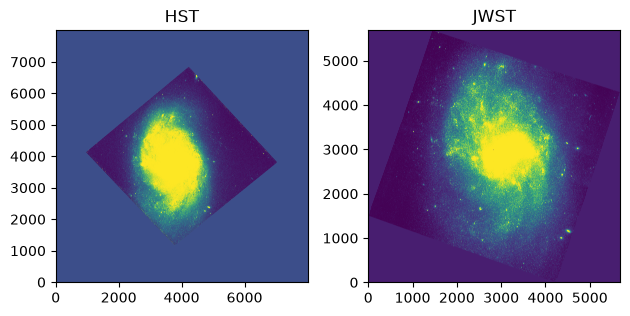

In [4]:
min_hst, max_hst = np.percentile(data_hst, [5, 95])
min_jwst, max_jwst = np.percentile(data_jwst, [5, 95])

fig, (ax1, ax2) = plt.subplots(1,2)
ax1.imshow(data_hst, cmap="viridis", origin="lower", vmin=min_hst, vmax=max_hst)
ax2.imshow(data_jwst, cmap="viridis", origin="lower", vmin=min_jwst, vmax=max_jwst)
ax1.set_title("HST")
ax2.set_title("JWST")
plt.tight_layout()
plt.show()


In [5]:
mean_hst, median_hst, std_hst = sigma_clipped_stats(data_hst, sigma=3.0, maxiters=5)
mean_jwst, median_jwst, std_jwst = sigma_clipped_stats(data_jwst, sigma=3.0, maxiters=5)

hst_dict = {"telescope": "HST", "mean": mean_hst, "median": median_hst, "std": std_hst}
jwst_dict = {"telescope": "JWST", "mean": mean_jwst, "median": median_jwst, "std": std_jwst}



In [6]:
df = pd.DataFrame([hst_dict, jwst_dict]).set_index("telescope")
print(df.to_string(float_format=lambda x: f"{x:.4e}"))

                 mean     median        std
telescope                                  
HST       -2.6647e-04 0.0000e+00 2.7948e-03
JWST       5.1636e-02 0.0000e+00 1.6925e-01


In [7]:
sky_subtracted_hst = data_hst - median_hst
sky_subtracted_jwst = data_jwst - median_jwst

daofind_hst = DAOStarFinder(fwhm = 2.5, threshold = 30 * std_hst)
daofind_jwst = DAOStarFinder(fwhm = 2.5, threshold = 30 * std_jwst)

In [8]:
sources_hst = daofind_hst(sky_subtracted_hst)
sources_jwst = daofind_jwst(sky_subtracted_jwst)

In [9]:
mask_hst = (
    (sources_hst['sharpness'] > 0.1) & (sources_hst['sharpness'] < 1.2) &
    (sources_hst['roundness2'] > -0.3) & (sources_hst['roundness2'] < 0.3)
)
mask_jwst = (
    (sources_jwst['sharpness'] > 0.1) & (sources_jwst['sharpness'] < 1.2) &
    (sources_jwst['roundness2'] > -0.3) & (sources_jwst['roundness2'] < 0.3)
)
sources_hst_clean = sources_hst[mask_hst]
sources_jwst_clean = sources_jwst[mask_jwst]

In [10]:
wcs_hst = WCS(header_hst)
wcs_jwst = WCS(header_jwst)

coords_hst = wcs_hst.pixel_to_world(sources_hst_clean["x_centroid"], sources_hst_clean["y_centroid"])
coords_jwst = wcs_jwst.pixel_to_world(sources_jwst_clean["x_centroid"], sources_jwst_clean["y_centroid"])

idx, d2d, d3d = coords_hst.match_to_catalog_sky(coords_jwst)


Set DATE-AVG to '2023-01-25T13:51:14.748' from MJD-AVG.
Set DATE-END to '2023-01-25T14:18:58.995' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.622808 from OBSGEO-[XYZ].
Set OBSGEO-H to 1660472184.749 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [11]:
d2d

<Angle [0.00743265, 0.00736161, 0.00707581, ..., 0.01597598, 0.01627994,
        0.0163108 ] deg>

In [12]:
# 1. Conversões básicas após o match_to_catalog_sky
separacao_arcsec = d2d.arcsec
coarse_pixel_scale = 0.04  # arcsec/pixel
offsets_pixels = separacao_arcsec / coarse_pixel_scale

# 2. Definir a máscara de fontes válidas (filtrando quem está muito longe)
limite_maximo = 0.2  # arcsec
validos = separacao_arcsec < limite_maximo

# 3. Aplicar o filtro e calcular a mediana
offsets_validos = offsets_pixels[validos]

print(f"Offsets individuais (em pixels): {offsets_validos[:5]}")
print(f"Offset mediano das fontes: {np.median(offsets_validos):.2f} pixels")

Offsets individuais (em pixels): [0.31711944 0.49774547 0.32185792 0.25200453 0.35801874]
Offset mediano das fontes: 0.26 pixels


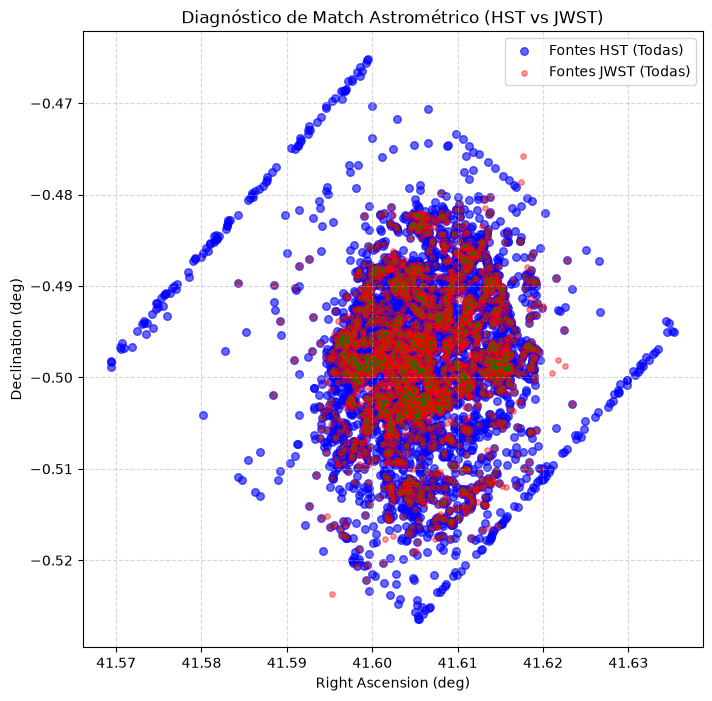

In [13]:
# Converte as coordenadas celestes para graus para facilitar o plot
ra_hst, dec_hst = coords_hst.ra.deg, coords_hst.dec.deg
ra_jwst, dec_jwst = coords_jwst.ra.deg, coords_jwst.dec.deg

plt.figure(figsize=(8, 8))

# Plota todas as fontes detectadas (para ver o campo geral)
plt.scatter(ra_hst, dec_hst, color='blue', s=30, alpha=0.6, label='Fontes HST (Todas)')
plt.scatter(ra_jwst, dec_jwst, color='red', s=15, alpha=0.4, label='Fontes JWST (Todas)')

# Plota linhas conectando os pares válidos que o match encontrou
for i in range(len(coords_hst)):
    if validos[i]:  # Apenas os pares que passaram no filtro de 0.2 arcsec
        plt.plot([ra_hst[i], ra_jwst[idx[i]]], 
                 [dec_hst[i], dec_jwst[idx[i]]], 
                 color='green', linestyle='-', alpha=0.7)

plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.title('Diagnóstico de Match Astrométrico (HST vs JWST)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Point Sources

In [15]:
# Fontes pontuais selecionadas no DS9 (NGC 1087), lidas no frame do HST/f814w.
# Servem como chute inicial: o centroid_2dg refina a posicao em cada imagem.
ra_sources  = [41.6036123, 41.6007478, 41.6135966, 41.6014181, 41.6173553]
dec_sources = [-0.5152057, -0.5130389, -0.5130459, -0.4820472, -0.4850417]

# Leitura no frame do JWST (mesma posicao do mouse). Nao usada na medida --
# serve so de registro; a diferenca entre as duas listas mede a precisao do
# posicionamento do mouse, nao o offset entre os WCS.
ra_sources_jwst  = [41.6036147, 41.6007488, 41.6135940, 41.6014187, 41.6173538]
dec_sources_jwst = [-0.5152044, -0.5130368, -0.5130478, -0.4820473, -0.4850403]

c = SkyCoord(ra_sources, dec_sources, frame = "icrs", unit = u.degree)

In [30]:
# Convert from world coordinates to pixel in each frame
# and calculate centroids

pix_hst = wcs_hst.world_to_pixel(c)
pix_jwst = wcs_jwst.world_to_pixel(c)

centroids_hst = centroid_sources(data_hst, xpos = pix_hst[0], ypos = pix_hst[1], box_size = 15, centroid_func = centroid_2dg)
centroids_jwst = centroid_sources(data_jwst, xpos = pix_jwst[0], ypos = pix_jwst[1], box_size = 7, centroid_func = centroid_2dg)

wcs_centroids_hst = wcs_hst.pixel_to_world(centroids_hst[0], centroids_hst[1])
wcs_centroids_jwst = wcs_jwst.pixel_to_world(centroids_jwst[0], centroids_jwst[1])

sep = wcs_centroids_hst.separation(wcs_centroids_jwst)

In [31]:
sep

<Angle [1.99933387e-06, 2.54128737e-06, 4.92830866e-07, 3.05425463e-06,
        2.42973597e-06] deg>

In [32]:
"""
Check 1 - WCS consistency between PHANGS-HST and PHANGS-JWST.

Measures the astrometric offset between the two surveys using point sources
present in both. Each source starts from ONE sky coordinate (read off the HST
frame in DS9); the centroid is then refined independently in each image, and
the separation between the two refined positions is the offset between the
WCS solutions.

Starting from a single coordinate matters: if the two starting positions were
marked by hand separately, the measurement would include the error of the
hand, which is of the same order as the effect being measured.

Criterion (set in advance): median offset < 0.5 pixel of the final grid.
"""

import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from photutils.centroids import centroid_sources, centroid_2dg

# ---------------------------------------------------------------- inputs ---
# Point sources selected in DS9 (NGC 1087), read off the HST/f814w frame.
# These are only the initial guess; centroid_2dg refines each one.
ra_sources = [41.6036123, 41.6007478, 41.6135966, 41.6014181, 41.6173553]
dec_sources = [-0.5152057, -0.5130389, -0.5130459, -0.4820472, -0.4850417]

# box_size is in PIXELS, so it must differ between images to cover the same
# patch of sky: 15 px x 0.0396"/px = 0.59" (HST); 7 px x 0.111"/px = 0.78" (JWST).
BOX_HST = 15
BOX_JWST = 7

# Pixel scale of the final cube grid, for reporting the offset in pixels.
# Read it from the cube header rather than hard-coding it when running for real.
FINAL_GRID_ARCSEC = 0.111

CRITERION_PX = 0.5


def measure_offsets(data_a, wcs_a, box_a, data_b, wcs_b, box_b, coords):
    """Refine the centroid of each source in both images and compare.

    Returns (separation, dra, ddec, shift_a, shift_b), where the first three
    are Angle arrays and the last two are the pixel distance each centroid
    moved from its initial guess - a large shift means the fit latched onto a
    neighbour and that source should not be trusted.
    """
    pix_a = wcs_a.world_to_pixel(coords)
    pix_b = wcs_b.world_to_pixel(coords)

    cen_a = centroid_sources(data_a, xpos=pix_a[0], ypos=pix_a[1],
                             box_size=box_a, centroid_func=centroid_2dg)
    cen_b = centroid_sources(data_b, xpos=pix_b[0], ypos=pix_b[1],
                             box_size=box_b, centroid_func=centroid_2dg)

    shift_a = np.hypot(cen_a[0] - pix_a[0], cen_a[1] - pix_a[1])
    shift_b = np.hypot(cen_b[0] - pix_b[0], cen_b[1] - pix_b[1])

    sky_a = wcs_a.pixel_to_world(cen_a[0], cen_a[1])
    sky_b = wcs_b.pixel_to_world(cen_b[0], cen_b[1])

    sep = sky_a.separation(sky_b)
    # spherical_offsets_to applies the cos(dec) factor internally
    dra, ddec = sky_a.spherical_offsets_to(sky_b)

    return sep, dra, ddec, shift_a, shift_b


def report(label, sep, dra, ddec, shift_a, shift_b, box_a, box_b,
           grid_arcsec):
    """Print the per-source table and the summary."""
    print(f"\n{'=' * 72}\n{label}\n{'=' * 72}")

    valid = np.isfinite(sep.arcsec)
    # a centroid that moved more than a third of the box probably jumped to a
    # neighbouring source
    jumped = (shift_a > box_a / 3) | (shift_b > box_b / 3)

    print(f"{'src':>4} {'sep (arcsec)':>13} {'sep (px)':>10} "
          f"{'dRA (arcsec)':>13} {'dDec (arcsec)':>14} "
          f"{'shift_a':>8} {'shift_b':>8}  flag")
    print("-" * 88)
    for i in range(len(sep)):
        flag = ""
        if not valid[i]:
            flag = "CENTROID FAILED"
        elif jumped[i]:
            flag = "large shift - check"
        print(f"{i + 1:>4} {sep.arcsec[i]:>13.4f} "
              f"{sep.arcsec[i] / grid_arcsec:>10.3f} "
              f"{dra.arcsec[i]:>+13.4f} {ddec.arcsec[i]:>+14.4f} "
              f"{shift_a[i]:>8.2f} {shift_b[i]:>8.2f}  {flag}")

    n_ok = int(valid.sum())
    if n_ok == 0:
        print("\nNo valid centroid. Check the coordinates and the box sizes.")
        return None

    med_arcsec = np.nanmedian(sep.arcsec)
    med_px = med_arcsec / grid_arcsec
    mean_dra = np.nanmean(dra.arcsec)
    mean_ddec = np.nanmean(ddec.arcsec)
    scatter = np.nanstd(sep.arcsec)

    print(f"\n  sources with a valid centroid : {n_ok} of {len(sep)}")
    print(f"  median separation             : {med_arcsec:.4f} arcsec "
          f"= {med_px:.3f} px of the final grid")
    print(f"  scatter (std)                 : {scatter:.4f} arcsec")
    print(f"  mean offset                   : dRA {mean_dra:+.4f}, "
          f"dDec {mean_ddec:+.4f} arcsec")

    # A systematic offset points the same way for every source; random error
    # alternates sign. Comparing the mean vector with the median separation
    # distinguishes the two.
    systematic = np.hypot(mean_dra, mean_ddec)
    if med_arcsec > 0:
        print(f"  systematic / median           : "
              f"{systematic / med_arcsec:.2f}  "
              f"({'mostly systematic' if systematic / med_arcsec > 0.7 else 'mostly random scatter'})")

    return med_px


# ------------------------------------------------------------------ main ---
if __name__ == "__main__":
    from pathlib import Path

    INPUT_PATH = Path("~/Research/AsTrovello/Input/").expanduser()
    hst_file = INPUT_PATH / (
        "PHANGS-HST/galaxies/ngc1087/"
        "hlsp_phangs-hst_hst_wfc3-uvis_ngc1087_f814w_v1_exp-drc-sci.fits")
    jwst_file = INPUT_PATH / (
        "PHANGS-JWST/galaxies/ngc1087/"
        "hlsp_phangs-jwst_jwst_nircam_ngc1087_f200w_v1p1_img.fits")

    # HST keeps the science image in HDU 0; JWST mosaics in HDU 1
    with fits.open(hst_file) as hdu:
        data_hst = hdu[0].data
        wcs_hst = WCS(hdu[0].header)
    with fits.open(jwst_file) as hdu:
        data_jwst = hdu[1].data
        wcs_jwst = WCS(hdu[1].header)

    coords = SkyCoord(ra_sources, dec_sources, frame="icrs", unit=u.deg)

    # --- sanity test: the same image on both sides must give exactly zero ---
    # If this is not zero, there is a bug in the coordinate chain and the real
    # measurement below cannot be trusted.
    res = measure_offsets(data_hst, wcs_hst, BOX_HST,
                          data_hst, wcs_hst, BOX_HST, coords)
    report("SANITY TEST - HST against itself (must be exactly zero)",
           *res, BOX_HST, BOX_HST, FINAL_GRID_ARCSEC)

    # --- the real measurement ---
    res = measure_offsets(data_hst, wcs_hst, BOX_HST,
                          data_jwst, wcs_jwst, BOX_JWST, coords)
    med_px = report("CHECK 1 - HST (f814w) against JWST (f200w)",
                    *res, BOX_HST, BOX_JWST, FINAL_GRID_ARCSEC)

    # --- verdict ---
    print(f"\n{'=' * 72}")
    if med_px is None:
        print("VERDICT: could not measure. Check the inputs.")
    elif med_px < CRITERION_PX:
        print(f"VERDICT: PASS - median {med_px:.3f} px < {CRITERION_PX} px. "
              f"The two surveys may be combined.")
    else:
        print(f"VERDICT: FAIL - median {med_px:.3f} px >= {CRITERION_PX} px. "
              f"Astrometric registration would be needed before combining.")
    print("=" * 72)


SANITY TEST - HST against itself (must be exactly zero)
 src  sep (arcsec)   sep (px)  dRA (arcsec)  dDec (arcsec)  shift_a  shift_b  flag
----------------------------------------------------------------------------------------
   1        0.0000      0.000       +0.0000        +0.0000     0.06     0.06  
   2        0.0000      0.000       +0.0000        -0.0000     0.16     0.16  
   3        0.0000      0.000       +0.0000        +0.0000     0.35     0.35  
   4        0.0000      0.000       +0.0000        +0.0000     0.26     0.26  
   5        0.0000      0.000       +0.0000        +0.0000     0.20     0.20  

  sources with a valid centroid : 5 of 5
  median separation             : 0.0000 arcsec = 0.000 px of the final grid
  scatter (std)                 : 0.0000 arcsec
  mean offset                   : dRA +0.0000, dDec +0.0000 arcsec

CHECK 1 - HST (f814w) against JWST (f200w)
 src  sep (arcsec)   sep (px)  dRA (arcsec)  dDec (arcsec)  shift_a  shift_b  flag
---------------

Set DATE-AVG to '2023-01-25T13:51:14.748' from MJD-AVG.
Set DATE-END to '2023-01-25T14:18:58.995' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.622808 from OBSGEO-[XYZ].
Set OBSGEO-H to 1660472184.749 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
